In [1]:
import numpy as np

import matplotlib.pyplot as plt
%matplotlib widget


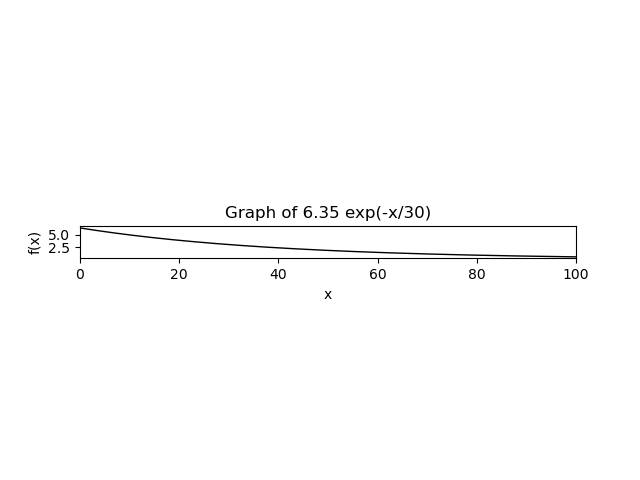

In [2]:

# Define the function
def f(x):
    return 6.35 * np.exp(-x / 40)

# Generate x values
x = np.linspace(0, 100, 1000)

# Generate y values
y = f(x)

# Plot the graph

plt.xlim(0, 100)
plt.gca().set_aspect('equal', adjustable='box')
plt.plot(x, y, label='6.35 exp(-x/30)',linewidth=1,color='k')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Graph of 6.35 exp(-x/30)')
plt.show()

In [5]:
# Define the x values at which we want to find the thickness
x_values = [0, 20, 40, 60, 80, 100]

# Interpolate the thickness values at the specified x values
thickness_values = np.interp(x_values, x, y)

# Print the results
for x_val, thickness in zip(x_values, thickness_values):
    print(f"Thickness at x={x_val}: {thickness}")

Thickness at x=0: 6.35
Thickness at x=20: 3.8514716197336067
Thickness at x=40: 2.3360362072669507
Thickness at x=60: 1.4168775815509376
Thickness at x=80: 0.8593794788873107
Thickness at x=100: 0.5212397412617573


In [7]:
from scipy.integrate import simps
from scipy.optimize import root_scalar

# Calculate the total integral from 0 to 100
total_integral = simps(y, x)

# Define the function to find the root of
def half_integral(x0):
    integral_x0 = simps(y[x <= x0], x[x <= x0])
    return integral_x0 - total_integral / 2

# Use a root-finding method to find x0
result = root_scalar(half_integral, bracket=[0, 100])
x0 = result.root

print(f"x0 where the integral of y from 0 to x0 is half the integral from 0 to 100: {x0}")

x0 where the integral of y from 0 to x0 is half the integral from 0 to 100: 24.624624624623138


/var/folders/k0/ns11dwnx4812f0h2qfq1dz2c0000gn/T/ipykernel_52613/96291252.py:5: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  total_integral = simps(y, x)
/var/folders/k0/ns11dwnx4812f0h2qfq1dz2c0000gn/T/ipykernel_52613/96291252.py:9: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  integral_x0 = simps(y[x <= x0], x[x <= x0])


In [12]:
np.sum(y) * np.mean(np.diff(x))

233.49443791820823

In [13]:
np.sum(y[x<x0]) * np.mean(np.diff(x))

116.90788381684844

In [14]:
116*2

232

In [15]:
x0

24.624624624623138